# Natural Language Processing. Assignment 1. Tokenization.

In this assignment, you need to implement, train, and analyze a Byte-Pair Encoding (BPE) tokenizer.

The assignment consist of 3 tasks. When you finish all the tasks, create a GitHub repository for this assignment (you can use this repository later for the other assignments) and submit this notebook in the repository. Leave `requirements.txt` file if your code requires additional installations. Submit the link to the repository in Moodle.

## Task 1: Data Preparation and Vocabulary Size Selection (3 points)

First, load the [Brown corpus](https://en.wikipedia.org/wiki/Brown_Corpus). After loading the corpus, you need to select the appropriate vocabulary size for the BPE tokenizer. The appropriate vocabulary size is the minimal vocabulary size that covers at least 90% of the words in the corpus. The coverage is calculated according to the following formula:



$$ \text{coverage}(k) = \frac{\sum_{r=1}^{k} f(r)}{\sum_{r=1}^{N} f(r)} $$



where $f(r)$ is the frequency of the top-$r$ word, $k$ is the number of top-$k$ tokens included in vocab, $N$ is the total unique words in corpus.

So, for this task you need to do the following:

1. Load the Brown corpus (0.5 points)
2. Plot cumulative coverage vs. vocabulary size for the loaded corpus (1 point)
3. Select the appropriate vocabulary size (0.5 point)
4. Answer the questions:
    1. Why the coverage slows down the increase as the vocabulary size increases? (0.5 point)
    2. Which empirical law explains the slowing down increase of the coverage? (0.5 point)

In [ ]:

# if you don't have nltk, run: !pip -q install nltk

import nltk
from nltk.corpus import brown
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# download the brown corpus
nltk.download("brown")


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


True

In [ ]:
# get all words from brown corpus
words = brown.words()

# make words lowercase and remove punctuation
# we only keep letters because numbers and symbols mess up the vocabulary
words = [w.lower() for w in words if w.isalpha()]

len(words), words[:20]


(981716,
 ['the',
  'fulton',
  'county',
  'grand',
  'jury',
  'said',
  'friday',
  'an',
  'investigation',
  'of',
  'recent',
  'primary',
  'election',
  'produced',
  'no',
  'evidence',
  'that',
  'any',
  'irregularities',
  'took'])

In [ ]:
# count how many times each word appears
freq = Counter(words)

# sort the frequencies from highest to lowest
counts_sorted = np.array(sorted(freq.values(), reverse=True))

N = len(counts_sorted)                  # how many different words we have
total = counts_sorted.sum()             # total times all words appear

# calculate cumulative coverage - how much of all words we cover with top k words
cum_counts = np.cumsum(counts_sorted)
coverage = cum_counts / total

N, total, coverage[:10], coverage[-1]


(40234,
 np.int64(981716),
 array([0.07127418, 0.10836433, 0.13775471, 0.16439989, 0.18802688,
        0.20976128, 0.22055258, 0.23084986, 0.24084766, 0.25057349]),
 np.float64(1.0))

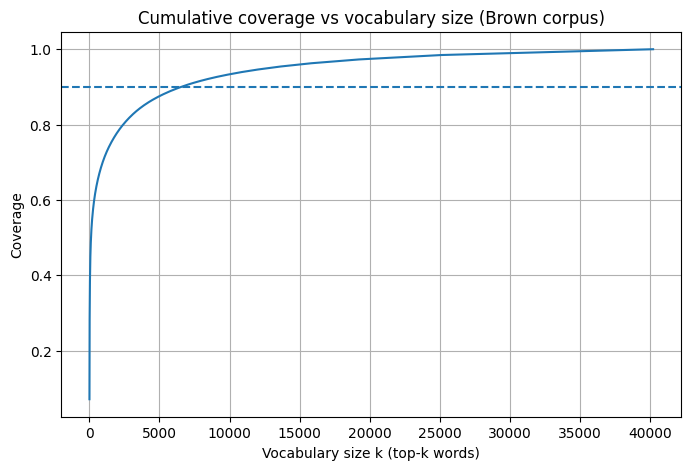

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, N+1), coverage)
plt.axhline(0.9, linestyle="--")
plt.title("Cumulative coverage vs vocabulary size (Brown corpus)")
plt.xlabel("Vocabulary size k (top-k words)")
plt.ylabel("Coverage")
plt.grid(True)
plt.show()


In [ ]:
target = 0.9
# find what position in the list reaches 90% coverage
k_star = int(np.searchsorted(coverage, target) + 1)  # +1 because we count from 1, not 0

k_star, coverage[k_star - 1]


(6545, np.float64(0.9000097787954968))

In [6]:
print(f"Minimal vocabulary size covering at least {target*100:.0f}% of tokens: k = {k_star}")
print(f"Coverage at k = {k_star}: {coverage[k_star - 1]:.4f}")
print(f"Unique words in corpus (N): {N}")


Minimal vocabulary size covering at least 90% of tokens: k = 6545
Coverage at k = 6545: 0.9000
Unique words in corpus (N): 40234


1) Why does the growth of coverage slow down when the vocabulary size increases?
Because the most frequent words cover a huge proportion of all usages, and then there remains a “long tail” of rare words: adding each new word gives a smaller increase in coverage.

2) What empirical law explains this slowdown?
Zipf's law: the frequency of a word is inversely proportional to its rank, so the distribution is highly skewed — there are few very frequent words and a lot of rare ones.

## Task 2: Implement Byte-Pair Encoding (BPE) Tokenizer (4 points)

Implement the [BPE tokenizer](https://arxiv.org/pdf/1508.07909) as the `BPETokenizer` class.

The class should contain correctly implemented:

* `train` method (1.5 points).
* `tokenize` method (1.5 points).

The code should have docstrings and comments (1 point).

In [11]:

# if you don't have tqdm, run: !pip -q install tqdm

from collections import Counter
from typing import Iterable, List, Tuple, Dict, Optional
from tqdm.auto import tqdm


class BPETokenizer:
    """
    BPE Tokenizer - breaks words into subword pieces.
    
    How it works:
    - learns merge rules from text (what pairs of characters go together)
    - each word starts as single letters + </w> marker at end
    - finds the most common pairs and merges them
    - when tokenizing, uses these learned rules to split words
    """

    def __init__(self, unk_token: str = "<unk>", eow: str = "</w>"):
        """
        set up the tokenizer with basic stuff
        unk_token: what to use for words we never saw
        eow: marker at end of word to know where words end
        """
        self.unk_token = unk_token
        self.eow = eow

        # list of merge rules we learn in order
        self.merges: List[Tuple[str, str]] = []
        # which merge rule is most important (learned first = most important)
        self.merge_ranks: Dict[Tuple[str, str], int] = {}

        # all the subword pieces we have (characters + merged pieces)
        self.vocab: set = set([unk_token, eow])

        # is the tokenizer ready to use?
        self.trained: bool = False

    # -----------------------
    # Helpers for BPE training
    # -----------------------

    @staticmethod
    def _word_to_symbols(word: str, eow: str) -> Tuple[str, ...]:
        """break word into letters and add end marker"""
        return tuple(list(word) + [eow])

    @staticmethod
    def _get_pair_counts(word_symbols_freq: Dict[Tuple[str, ...], int]) -> Counter:
        """
        count how often pairs of letters appear next to each other
        """
        pair_counts = Counter()
        for symbols, freq in word_symbols_freq.items():
            for i in range(len(symbols) - 1):
                pair_counts[(symbols[i], symbols[i + 1])] += freq
        return pair_counts

    @staticmethod
    def _merge_pair_in_symbols(symbols: Tuple[str, ...], pair: Tuple[str, str]) -> Tuple[str, ...]:
        """
        join a pair of letters everywhere they appear
        example: l + o = lo
        """
        a, b = pair
        merged = []
        i = 0
        while i < len(symbols):
            # if we find the pair, join them
            if i < len(symbols) - 1 and symbols[i] == a and symbols[i + 1] == b:
                merged.append(a + b)
                i += 2  # skip both letters since we merged them
            else:
                merged.append(symbols[i])
                i += 1
        return tuple(merged)

    # -----------------------
    # Required methods
    # -----------------------

    def train(
        self,
        corpus_words: Iterable[str],
        vocab_size: int,
        lowercase: bool = True,
        max_vocab_words: Optional[int] = 30000,
        min_word_freq: int = 2,
        show_progress: bool = True,
    ) -> None:
        """
        train the tokenizer to learn merge rules
        corpus_words: the text we learn from
        vocab_size: how many subword pieces we want (like 5000 or 10000)
        lowercase: make all words lowercase?
        max_vocab_words: only use most common words (faster)
        min_word_freq: ignore words that appear less than this
        show_progress: show a progress bar?
        """
        if vocab_size < 2:
            raise ValueError("vocab size must be at least 2")

        # count word frequencies
        if lowercase:
            corpus_words = (w.lower() for w in corpus_words)

        word_freq = Counter(corpus_words)

        # remove very rare words to make it faster
        if min_word_freq > 1:
            word_freq = Counter({w: c for w, c in word_freq.items() if c >= min_word_freq})

        # only use the most common words
        if max_vocab_words is not None and len(word_freq) > max_vocab_words:
            word_freq = Counter(dict(word_freq.most_common(max_vocab_words)))

        # convert words to letters (like 'cat' becomes ['c','a','t','</w>'])
        word_symbols_freq: Dict[Tuple[str, ...], int] = {
            self._word_to_symbols(word, self.eow): freq
            for word, freq in word_freq.items()
            if word
        }

        # collect all unique letters
        chars = set()
        for sym_seq in word_symbols_freq.keys():
            chars.update(sym_seq)

        # start with just letters, then we'll add merged pieces
        self.vocab = set(chars) | {self.unk_token}
        self.merges = []
        self.merge_ranks = {}

        # how many pairs do we need to merge?
        merges_to_do = max(0, vocab_size - len(self.vocab))

        iterator = range(merges_to_do)
        if show_progress:
            iterator = tqdm(iterator, desc="BPE training (merges)", total=merges_to_do)

        # main training loop
        for _ in iterator:
            # count all pairs of letters
            pair_counts = self._get_pair_counts(word_symbols_freq)
            if not pair_counts:
                break

            # find the most common pair
            best_pair, best_count = pair_counts.most_common(1)[0]

            # if pair only appears once, stop (not worth merging)
            if best_count < 2:
                break

            # merge this pair everywhere it appears
            new_word_symbols_freq: Dict[Tuple[str, ...], int] = {}
            for sym_seq, freq in word_symbols_freq.items():
                new_seq = self._merge_pair_in_symbols(sym_seq, best_pair)
                new_word_symbols_freq[new_seq] = new_word_symbols_freq.get(new_seq, 0) + freq
            word_symbols_freq = new_word_symbols_freq

            # remember this merge rule
            self.merge_ranks[best_pair] = len(self.merges)
            self.merges.append(best_pair)

            # add the new merged piece to vocabulary
            merged_symbol = best_pair[0] + best_pair[1]
            self.vocab.add(merged_symbol)

            # stop when we have enough pieces
            if len(self.vocab) >= vocab_size:
                break

        # done training!
        self.trained = True

    def tokenize_word(self, word: str, lowercase: bool = True) -> List[str]:
        """
        split one word using what we learned
        - break word into letters
        - use our merge rules in order
        - return the final pieces
        """
        if not self.trained:
            raise RuntimeError("train the tokenizer first!")

        if lowercase:
            word = word.lower()

        # break word into letters
        symbols = list(self._word_to_symbols(word, self.eow))

        # keep merging pairs following what we learned
        while True:
            # find all pairs of letters next to each other
            pairs = [(symbols[i], symbols[i + 1]) for i in range(len(symbols) - 1)]
            # find which pairs we know how to merge
            candidates = [p for p in pairs if p in self.merge_ranks]
            if not candidates:
                break

            # pick the most important merge (learned first)
            best = min(candidates, key=lambda p: self.merge_ranks[p])

            a, b = best
            merged = []
            i = 0
            while i < len(symbols):
                # if we find this pair, join them
                if i < len(symbols) - 1 and symbols[i] == a and symbols[i + 1] == b:
                    merged.append(a + b)
                    i += 2
                else:
                    merged.append(symbols[i])
                    i += 1
            symbols = merged

        # remove the end marker
        if symbols and symbols[-1] == self.eow:
            symbols = symbols[:-1]

        return symbols

    def tokenize(self, text: str, lowercase: bool = True) -> List[str]:
        """
        split text into pieces
        - split by spaces to get words
        - split each word
        - return all pieces
        """
        if not self.trained:
            raise RuntimeError("train the tokenizer first!")

        # split text into words
        words = text.split()
        out: List[str] = []
        # split each word and collect all pieces
        for w in words:
            out.extend(self.tokenize_word(w, lowercase=lowercase))
        return out


In [ ]:
# test the tokenizer

# get words from brown corpus (same as task 1)
words_for_bpe = [w.lower() for w in brown.words() if w.isalpha()]

bpe = BPETokenizer()
vocab_size_bpe = 10000  # 10000 pieces
bpe.train(
    words_for_bpe,
    vocab_size=vocab_size_bpe,
    max_vocab_words=30000,
    min_word_freq=2,
    show_progress=True
)

print("Trained merges:", len(bpe.merges))
print("Final vocab size (approx):", len(bpe.vocab))

# try splitting a sentence
test_text = "Tokenization with BPE is surprisingly effective"
print(bpe.tokenize(test_text))


BPE training (merges):   0%|          | 0/9972 [00:00<?, ?it/s]

In [ ]:
# check some examples
print("tokenization ->", bpe.tokenize_word("tokenization"))
print("effective ->", bpe.tokenize_word("effective"))
print("first 10 merges:", bpe.merges[:10])


tokenization -> ['to', 'ken', 'i', 'zation</w>']
effective -> ['effective</w>']
first 10 merges: [('e', '</w>'), ('t', 'h'), ('s', '</w>'), ('d', '</w>'), ('t', '</w>'), ('n', '</w>'), ('e', 'r'), ('th', 'e</w>'), ('i', 'n'), ('y', '</w>')]


## Task 3: Tokenizer Training and Analysis (3 points)

1. Train the `BPETokenizer` on the Brown corpus with the appropriate vocabulary size selected in Task 1 (1 points)
2. Use the Brown corpus (1000 samples) to calculate the mean and standard deviation of
    * tokenizer's fertility (1 points)
    * length of the tokenized sentence (1 points)

In [ ]:
# Task 3: train and analyze tokenizer
# get 1000 sentences from brown corpus
sentences = brown.sents()[:1000]
sentences_words = [[w.lower() for w in sent if w.isalpha()] for sent in sentences]
# remove empty sentences
sentences_words = [sent for sent in sentences_words if sent]

print(f"Got {len(sentences_words)} sentences")

# train tokenizer with vocab size from task 1
bpe_task3 = BPETokenizer()
bpe_task3.train(
    words_for_bpe,
    vocab_size=k_star,  # the 90% coverage size from task 1
    max_vocab_words=30000,
    min_word_freq=2,
    show_progress=True
)

print(f"Trained with vocab_size={k_star}")
print(f"Actual vocab size: {len(bpe_task3.vocab)}")
print(f"Learned merges: {len(bpe_task3.merges)}")

# calculate statistics
# fertility = how many pieces per word on average
# token length = how many pieces per sentence

token_lens = []
fertilities = []

for sent_words in sentences_words:
    text = " ".join(sent_words)
    bpe_tokens = bpe_task3.tokenize(text)

    n_words = len(sent_words)
    n_bpe = len(bpe_tokens)

    token_lens.append(n_bpe)
    if n_words > 0:
        # fertility = pieces divided by original words
        fertilities.append(n_bpe / n_words)

token_lens = np.array(token_lens, dtype=float)
fertilities = np.array(fertilities, dtype=float)

print("Tested on:", len(sentences_words), "sentences")

print("\nFertility (pieces per word):")
print("Mean:", fertilities.mean())
print("Std: ", fertilities.std(ddof=1))

print("\nTokens per sentence:")
print("Mean:", token_lens.mean())
print("Std: ", token_lens.std(ddof=1))


Extracted 995 sentences for analysis


BPE training (merges):   0%|          | 0/6517 [00:00<?, ?it/s]

Trained BPE with vocab_size=6545
Actual vocab size: 6545
Number of learned merges: 6517
Samples used: 995

Tokenizer fertility (BPE_tokens / words):
Mean: 1.2654032918286997
Std:  0.2853870563448009

Tokenized sentence length (#BPE tokens per sentence):
Mean: 23.18391959798995
Std:  13.087053469926534


## Grading Procedure Details

During the grading of the completed assignments, a random set of students will be sampled for the **offline assignment defence**. The defence will be arranged shortly after the assignment submission deadline. The particular date and time will be announced later.

The aim of the assignment defence is to ensure the students understand well their own solutions and know how thier solution works. To check this, the students will be asked various questions about the provided solution. In addition, the students will be asked to run their solution to ensure the solution works without errors.

Examples of questions:

1. How the cumulative coverage is calculated? Why is it called cumulative?
2. What is the rank of a word?
3. How does the BPE tokenizer work? Note: for this question, the students will not be able to see the their own implementation.
4. Why do you consider such vocabulary size appropriate?
5. What is the formula for the fertility of the tokenizer?
6. How do you perform pre-tokenization in your implementation?
7. How do you handle stopwords in the training corpus? Why?
8. etc.

As a result of the assignment defence, the grade for the assignment may be adjusted.